In [1]:
import torch

data_2d_dir = "/home/hlcao2/Diffusion_model_project/dataset_3d/x/U_2d.pt"
data_2d = torch.load(data_2d_dir)
print(data_2d.shape)

data_3d_dir = "/home/hlcao2/Diffusion_model_project/dataset_3d/x/U.pt"
data_3d = torch.load(data_3d_dir)
print(data_3d.shape)

data = torch.cat((data_2d, data_3d), dim=0)
print(data.shape)
torch.save(data, "/home/hlcao2/Diffusion_model_project/dataset_3d/x/U_all.pt")

torch.Size([100, 11, 3, 256, 256])
torch.Size([100, 11, 3, 256, 256])
torch.Size([200, 11, 3, 256, 256])


36
torch.Size([11, 3])


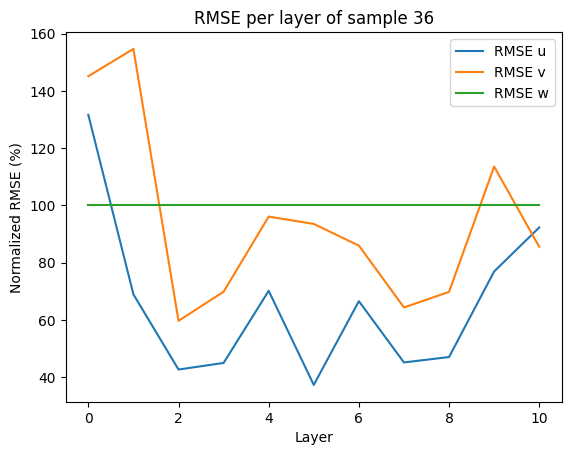

In [2]:
# select a random microstructure sample
import numpy as np
idx = np.random.randint(0, data_2d.shape[0])
print(idx)
data_2d_sample = data_2d[idx, :, :, :, :]
data_3d_sample = data_3d[idx, :, :, :, :]

# calculate rmse between data_2d and data_3d
rmse = torch.sqrt(torch.mean((data_2d_sample - data_3d_sample) ** 2, dim=[-1, -2]))
mean = torch.sqrt(torch.mean((data_3d_sample) ** 2, dim=[-1, -2]))
norm_rmse = 100* rmse / mean
print(rmse.shape)

# plot rmse per layer (2nd dimension)
import matplotlib.pyplot as plt

plt.plot(norm_rmse[:, 0], label="RMSE u")
plt.plot(norm_rmse[:, 1], label="RMSE v")
plt.plot(norm_rmse[:, 2], label="RMSE w")
plt.xlabel("Layer")
plt.ylabel("Normalized RMSE (%)")
plt.title("RMSE per layer of sample " + str(idx))
plt.legend()
plt.show()
